In [13]:
import json
import torch
from torch import nn
import matplotlib.pyplot as plt
import tiktoken
from torch.utils.data import DataLoader


# ==================== 配置 ====================
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_size": 1024,
    "num_layers": 12,
    "num_heads": 12,
    "hidden_size": 768,
    "drop_rate": 0.1,
    "qkv_bias": True,
}



def format_input(entry):
    instruction = (
        f"Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n"
        f"### Instruction:\n{entry['instruction']}"
    )
    inputs = f"### Input:\n\n{entry['input']}" if entry["input"] else ""
    return instruction + inputs


def tokens_to_text(tokens, tokenizer):
    tokens = tokens.squeeze(0).tolist()
    return tokenizer.decode(tokens)


def text_to_tokens(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded, dtype=torch.long).unsqueeze(0)


# ==================== 模型组件类 ====================
class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.shift = nn.Parameter(torch.zeros(cfg["hidden_size"]))
        self.scale = nn.Parameter(torch.ones(cfg["hidden_size"]))
        self.eps = 1e-5
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2/torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(cfg["hidden_size"], 4*cfg["hidden_size"]),
            GELU(),
            nn.Linear(4*cfg["hidden_size"], cfg["hidden_size"])
        )
    
    def forward(self, x):
        return self.fc(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.head_dim = cfg["hidden_size"] // cfg["num_heads"]
        self.num_heads = cfg["num_heads"]
        self.w_q = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_k = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_v = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_o = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.register_buffer("mask",
                torch.triu(torch.ones(cfg["context_size"], cfg["context_size"]), diagonal=1).bool()
        )
    
    def forward(self, x):
        b, t, c = x.size()
        q = self.w_q(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.w_k(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.w_v(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = (q @ k.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))
        attn_scores = attn_scores.masked_fill(self.mask[:t, :t], float('-inf'))
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        attn_output = attn_weights @ v
        attn_output = attn_output.transpose(1, 2).contiguous().view(b, t, c)
        return self.w_o(attn_output)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.norm1 = LayerNorm(cfg)
        self.norm2 = LayerNorm(cfg)
        self.attn = MultiHeadAttention(cfg)
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.ffn = FeedForward(cfg)
    
    def forward(self, x):
        short_cut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.dropout(x)
        x = x + short_cut

        short_cut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + short_cut
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embedding = nn.Embedding(cfg["vocab_size"], cfg["hidden_size"])
        self.pos_emb = nn.Embedding(cfg["context_size"], cfg["hidden_size"])
        self.drop = nn.Dropout(cfg["drop_rate"])
        self.blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["num_layers"])]
        )
        self.final_norm = LayerNorm(cfg)
        self.out_head = nn.Linear(cfg["hidden_size"], cfg["vocab_size"], bias=False)
    
    def forward(self, idx):
        b, t = idx.size()
        token_emb = self.embedding(idx)  
        pos_emb = self.pos_emb(torch.arange(t, device=idx.device))
        x = self.drop(token_emb + pos_emb) 
        x = self.blocks(x)  
        x = self.final_norm(x) 
        return self.out_head(x) 


# ==================== 生成和训练函数 ====================
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, topk=None, eos_token_id=50256):
    is_training = model.training
    model.eval()
    for _ in range(max_new_tokens):
        idx_used = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_used)[:, -1, :]
        if topk is not None:
            topk_logits, _ = torch.topk(logits, topk)
            logits = torch.where(
                condition=logits < topk_logits[..., [-1]],
                input=torch.tensor(float('-inf')),
                other=logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            next_token = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)
        else:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        
        idx = torch.cat([idx, next_token], dim=1)
        
        if next_token.item() == eos_token_id:
            break
    
    if is_training:
        model.train()
    return idx


def calculate_loss_single_batch(inputs, targets, model, device):
    criterion = nn.CrossEntropyLoss()
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)
    loss = criterion(outputs.flatten(0, 1), targets.view(-1))
    return loss


def calculate_loss(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    num_batches = min(num_batches, len(data_loader)) if num_batches is not None else len(data_loader)
    for i, (inputs, labels) in enumerate(data_loader):
        if i >= num_batches:
            break
        with torch.no_grad():
            loss = calculate_loss_single_batch(inputs, labels, model, device)
        total_loss += loss.item()
    average_loss = total_loss / num_batches if num_batches > 0 else 0
    return average_loss


def train_loader_f(train_loader, val_loader, model, optimizer, device, num_epochs, val_freq):
    train_losses, val_losses, examples_seen = [], [], []
    global_steps = 0
    for epoch in range(num_epochs):
        model.train()
        for i, (inputs, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            loss = calculate_loss_single_batch(inputs, labels, model, device)
            loss.backward()
            optimizer.step()
            if global_steps % val_freq == 0:
                train_loss = calculate_loss(train_loader, model, device)
                val_loss = calculate_loss(val_loader, model, device)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                examples_seen.append((global_steps + 1) * inputs.shape[0])
                print(f"Epoch {epoch+1}/{num_epochs}, global steps: {global_steps+1}",
                    f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

            global_steps += 1
    return train_losses, val_losses, examples_seen


def plot_values(epochs_seen, examples_seen, train_values, val_values, label='loss'):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f'Train {label}')
    ax1.plot(epochs_seen, val_values, label=f'Val {label}', linestyle='-.')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(label)
    ax1.legend(loc='best')
    
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel('Examples Seen')
    plt.title(f'Train and Val {label} vs Epochs and Examples Seen')
    plt.show()


# ==================== 数据集相关 ====================
class InstructionDataset:
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_data = []
        for entry in self.data:
            formatted_text = format_input(entry)
            full_text = formatted_text + "\n\n### Response:\n" + entry["output"]
            encoded_entry = tokenizer.encode(full_text)
            self.encoded_data.append(encoded_entry)
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.encoded_data[idx]


def custom_collate_fn(batch, pad_token_id=50256, ignore_id=-100, all_max_length=1024):
    inputs, targets = [], []
    max_length = max(len(item)+1 for item in batch)
    
    for item in batch:
        new_item = item.copy()
        new_item = new_item + [pad_token_id] * (max_length - len(item))

        input_tensor = torch.tensor(new_item[:-1], dtype=torch.long)
        target_tensor = torch.tensor(new_item[1:], dtype=torch.long)
        mask = target_tensor == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            target_tensor[indices[1:]] = ignore_id

        if all_max_length is not None:
            input_tensor = input_tensor[:all_max_length]
            target_tensor = target_tensor[:all_max_length]
        
        inputs.append(input_tensor)
        targets.append(target_tensor)

    return torch.stack(inputs), torch.stack(targets)




In [14]:
def get_model(cfg, device, file_path, grid_allowed_modules=None):
    model = GPTModel(cfg)
    model.load_state_dict(torch.load(file_path))
    if grid_allowed_modules is not None:
        for param in model.parameters():
            param.requires_grad = False
        try:
            for module_name in grid_allowed_modules:
                for param in eval(f"model.{module_name}").parameters():
                    param.requires_grad = True
                print(f"Unfrozen module: {module_name}")
        except Exception as e:
            print(f"Error freezing modules: {e}")
            raise e
    else:
        print(f"all not frozen")
    model.to(device)
    return model

In [15]:
with open("E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter7\instruction-data.json", 'r', encoding='utf-8') as f:
    data = json.load(f)
print(data[0])

{'instruction': 'Evaluate the following phrase by transforming it into the spelling given.', 'input': 'freind --> friend', 'output': 'The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".'}


In [16]:
train_num = int(len(data) * 0.85)
test_num = int(len(data) * 0.1)
val_num = len(data) - train_num - test_num
train_data = data[:train_num]
test_data = data[train_num : train_num + test_num]
val_data = data[train_num + test_num :]
print(f"Train data: {len(train_data)} entries")

Train data: 935 entries


In [17]:
batch_size = 8

tokenizer = tiktoken.get_encoding('gpt2')
train_dataset = InstructionDataset(train_data ,tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=True,
    drop_last=True,
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=custom_collate_fn,
    shuffle=False,
    drop_last=False
)

In [18]:
print(tokenizer.max_token_value)

50256


In [19]:
i = 0
for ins, tars in train_loader:
    print(ins.shape, "  ", tars.shape)
    i += 1
    if i==5:

        break

torch.Size([8, 63])    torch.Size([8, 63])
torch.Size([8, 74])    torch.Size([8, 74])
torch.Size([8, 62])    torch.Size([8, 62])
torch.Size([8, 66])    torch.Size([8, 66])
torch.Size([8, 67])    torch.Size([8, 67])


## 全部进行微调

C:\Users\86178\AppData\Local\Temp\ipykernel_17340\3368253407.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


all not frozen
Initial Train Loss: 4.1009, Initial Val Loss: 4.1180
Epoch 1/2, global steps: 1 Train Loss: 2.8606, Val Loss: 2.8616
Epoch 1/2, global steps: 21 Train Loss: 1.0311, Val Loss: 1.0953
Epoch 1/2, global steps: 41 Train Loss: 0.8617, Val Loss: 0.9443
Epoch 1/2, global steps: 61 Train Loss: 0.7890, Val Loss: 0.9023
Epoch 1/2, global steps: 81 Train Loss: 0.7011, Val Loss: 0.8460
Epoch 1/2, global steps: 101 Train Loss: 0.6569, Val Loss: 0.8493
Epoch 2/2, global steps: 121 Train Loss: 0.5779, Val Loss: 0.8254
Epoch 2/2, global steps: 141 Train Loss: 0.5391, Val Loss: 0.8421
Epoch 2/2, global steps: 161 Train Loss: 0.5093, Val Loss: 0.8197
Epoch 2/2, global steps: 181 Train Loss: 0.4797, Val Loss: 0.8119
Epoch 2/2, global steps: 201 Train Loss: 0.4484, Val Loss: 0.7985
Epoch 2/2, global steps: 221 Train Loss: 0.4297, Val Loss: 0.7977


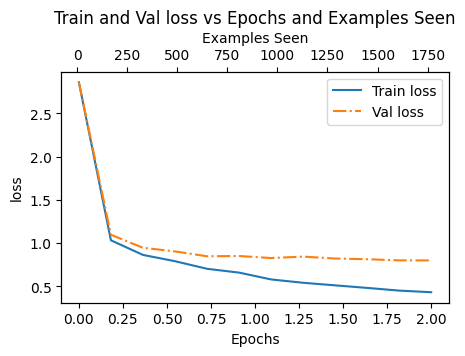

In [20]:

allowed_modules = None
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model12 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model12.parameters(), lr=2e-4, weight_decay=0.05)
model12.eval()
t_loss, val_loss = calculate_loss(train_loader, model12, device="cuda", num_batches=10), calculate_loss(val_loader, model12, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 2
val_freq = 20

train_losses, val_losses, examples_seen = train_loader_f(train_loader, val_loader, model12, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(torch.linspace(0, num_epochs, len(train_losses)), examples_seen, train_losses, val_losses)

C:\Users\86178\AppData\Local\Temp\ipykernel_17340\3368253407.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


all not frozen
Initial Train Loss: 4.0610, Initial Val Loss: 4.1180
Epoch 1/2, global steps: 1 Train Loss: 3.2168, Val Loss: 3.2354
Epoch 1/2, global steps: 21 Train Loss: 1.1032, Val Loss: 1.1257
Epoch 1/2, global steps: 41 Train Loss: 0.9169, Val Loss: 0.9603
Epoch 1/2, global steps: 61 Train Loss: 0.8332, Val Loss: 0.9170
Epoch 1/2, global steps: 81 Train Loss: 0.7676, Val Loss: 0.8901
Epoch 1/2, global steps: 101 Train Loss: 0.7126, Val Loss: 0.8612
Epoch 2/2, global steps: 121 Train Loss: 0.6710, Val Loss: 0.8451
Epoch 2/2, global steps: 141 Train Loss: 0.6184, Val Loss: 0.8292
Epoch 2/2, global steps: 161 Train Loss: 0.5928, Val Loss: 0.8445
Epoch 2/2, global steps: 181 Train Loss: 0.5550, Val Loss: 0.7994
Epoch 2/2, global steps: 201 Train Loss: 0.5381, Val Loss: 0.7965
Epoch 2/2, global steps: 221 Train Loss: 0.5144, Val Loss: 0.7899


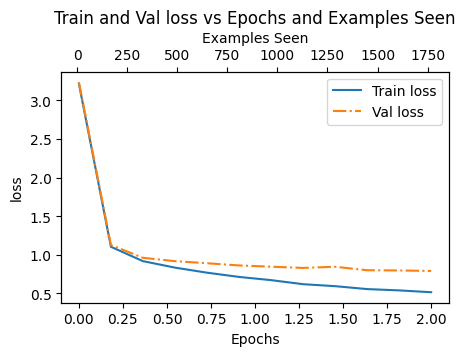

In [9]:

allowed_modules = None
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model1 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model1.parameters(), lr=1e-4, weight_decay=0.01)
model1.eval()
t_loss, val_loss = calculate_loss(train_loader, model1, device="cuda", num_batches=10), calculate_loss(val_loader, model1, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 2
val_freq = 20

train_losses, val_losses, examples_seen = train_loader_f(train_loader, val_loader, model1, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(torch.linspace(0, num_epochs, len(train_losses)), examples_seen, train_losses, val_losses)

## out_head & final_norm & blocks[-1]

C:\Users\86178\AppData\Local\Temp\ipykernel_17340\3368253407.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Unfrozen module: final_norm
Unfrozen module: blocks[-1]
Initial Train Loss: 4.1062, Initial Val Loss: 4.1180
Epoch 1/2, global steps: 1 Train Loss: 3.9216, Val Loss: 3.9491
Epoch 1/2, global steps: 21 Train Loss: 1.7988, Val Loss: 1.8048
Epoch 1/2, global steps: 41 Train Loss: 1.4301, Val Loss: 1.4775
Epoch 1/2, global steps: 61 Train Loss: 1.2895, Val Loss: 1.3604
Epoch 1/2, global steps: 81 Train Loss: 1.1888, Val Loss: 1.2955
Epoch 1/2, global steps: 101 Train Loss: 1.1114, Val Loss: 1.2329
Epoch 2/2, global steps: 121 Train Loss: 1.0431, Val Loss: 1.1729
Epoch 2/2, global steps: 141 Train Loss: 0.9993, Val Loss: 1.1768
Epoch 2/2, global steps: 161 Train Loss: 0.9621, Val Loss: 1.1643
Epoch 2/2, global steps: 181 Train Loss: 0.9244, Val Loss: 1.1510
Epoch 2/2, global steps: 201 Train Loss: 0.8938, Val Loss: 1.1096
Epoch 2/2, global steps: 221 Train Loss: 0.8621, Val Loss: 1.0899


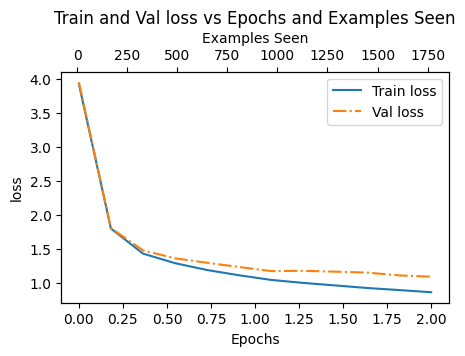

In [10]:

allowed_modules = ["out_head", "final_norm", "blocks[-1]"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model2 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model2.parameters(), lr=2e-4, weight_decay=0.01)
model2.eval()
t_loss, val_loss = calculate_loss(train_loader, model2, device="cuda", num_batches=10), calculate_loss(val_loader, model2, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 2
val_freq = 20

train_losses, val_losses, examples_seen = train_loader_f(train_loader, val_loader, model2, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(torch.linspace(0, num_epochs, len(train_losses)), examples_seen, train_losses, val_losses)

C:\Users\86178\AppData\Local\Temp\ipykernel_17340\3368253407.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Unfrozen module: final_norm
Unfrozen module: blocks[-1]
Initial Train Loss: 4.1037, Initial Val Loss: 4.1180
Epoch 1/2, global steps: 1 Train Loss: 3.6964, Val Loss: 3.6893
Epoch 1/2, global steps: 21 Train Loss: 1.5245, Val Loss: 1.5514
Epoch 1/2, global steps: 41 Train Loss: 1.2781, Val Loss: 1.3682
Epoch 1/2, global steps: 61 Train Loss: 1.1559, Val Loss: 1.2830
Epoch 1/2, global steps: 81 Train Loss: 1.0562, Val Loss: 1.2134
Epoch 1/2, global steps: 101 Train Loss: 0.9754, Val Loss: 1.1104
Epoch 2/2, global steps: 121 Train Loss: 0.9057, Val Loss: 1.1173
Epoch 2/2, global steps: 141 Train Loss: 0.8590, Val Loss: 1.0968
Epoch 2/2, global steps: 161 Train Loss: 0.8139, Val Loss: 1.0677
Epoch 2/2, global steps: 181 Train Loss: 0.7833, Val Loss: 1.0799
Epoch 2/2, global steps: 201 Train Loss: 0.7542, Val Loss: 1.0516
Epoch 2/2, global steps: 221 Train Loss: 0.7148, Val Loss: 1.0328


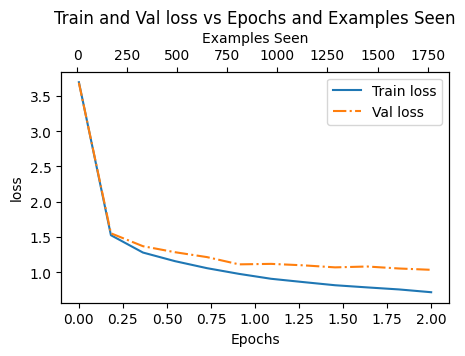

In [11]:

allowed_modules = ["out_head", "final_norm", "blocks[-1]"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model21 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model21.parameters(), lr=4e-4, weight_decay=0.01)
model21.eval()
t_loss, val_loss = calculate_loss(train_loader, model21, device="cuda", num_batches=10), calculate_loss(val_loader, model21, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 2
val_freq = 20

train_losses, val_losses, examples_seen = train_loader_f(train_loader, val_loader, model21, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(torch.linspace(0, num_epochs, len(train_losses)), examples_seen, train_losses, val_losses)

## out_head & final_norm & block * 6

C:\Users\86178\AppData\Local\Temp\ipykernel_17340\3368253407.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(file_path))


Unfrozen module: out_head
Unfrozen module: final_norm
Unfrozen module: blocks[-1]
Unfrozen module: blocks[-2]
Unfrozen module: blocks[-3]
Unfrozen module: blocks[-4]
Unfrozen module: blocks[-5]
Unfrozen module: blocks[-6]
Initial Train Loss: 4.0689, Initial Val Loss: 4.1180
Epoch 1/2, global steps: 1 Train Loss: 3.1155, Val Loss: 3.1256
Epoch 1/2, global steps: 21 Train Loss: 1.1287, Val Loss: 1.1582
Epoch 1/2, global steps: 41 Train Loss: 0.9825, Val Loss: 1.0532
Epoch 1/2, global steps: 61 Train Loss: 0.8719, Val Loss: 0.9994
Epoch 1/2, global steps: 81 Train Loss: 0.7982, Val Loss: 0.9280
Epoch 1/2, global steps: 101 Train Loss: 0.7435, Val Loss: 0.8914
Epoch 2/2, global steps: 121 Train Loss: 0.6803, Val Loss: 0.8875
Epoch 2/2, global steps: 141 Train Loss: 0.6364, Val Loss: 0.8960
Epoch 2/2, global steps: 161 Train Loss: 0.6039, Val Loss: 0.8830
Epoch 2/2, global steps: 181 Train Loss: 0.5813, Val Loss: 0.8865
Epoch 2/2, global steps: 201 Train Loss: 0.5504, Val Loss: 0.8587
Epoch

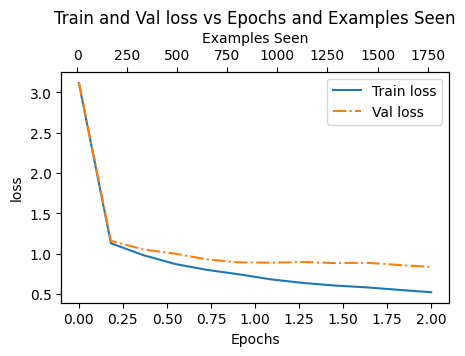

In [12]:

allowed_modules = ["out_head", "final_norm", "blocks[-1]", "blocks[-2]", "blocks[-3]", "blocks[-4]", "blocks[-5]", "blocks[-6]"]
file_path = "E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"
model3 = get_model(GPT_CONFIG_124M, device="cuda", file_path=file_path, grid_allowed_modules=allowed_modules)
optimizer = torch.optim.AdamW(model3.parameters(), lr=2e-4, weight_decay=0.01)
model3.eval()
t_loss, val_loss = calculate_loss(train_loader, model3, device="cuda", num_batches=10), calculate_loss(val_loader, model3, device="cuda", num_batches=10)
print(f"Initial Train Loss: {t_loss:.4f}, Initial Val Loss: {val_loss:.4f}")

num_epochs = 2
val_freq = 20

train_losses, val_losses, examples_seen = train_loader_f(train_loader, val_loader, model3, optimizer, device="cuda", num_epochs=num_epochs, val_freq=val_freq)

plot_values(torch.linspace(0, num_epochs, len(train_losses)), examples_seen, train_losses, val_losses)